In [1]:
# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2
%cd ..

/home/cneves/projects/EEG-DimentiaMamba/src


In [ ]:
import os
import matplotlib.pyplot as plt
os.environ['NUMEXPR_MAX_THREADS'] = '8'
os.environ['HYDRA_FULL_ERROR'] = '1'
import hydra
from hydra import compose, initialize
import torch
import numpy as np
from scipy.stats import sem
from utils import set_seed, get_num_class_labels
from utils import set_seed
import mne
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pandas as pd

from omegaconf import OmegaConf as OC
from pathlib import Path
import pyarrow.feather as feather
import glob
import pprint

from paths import CAUEEG_FM, CAUEEG_RAW, ROOT
from data import (
    get_create_filemarkers, 
    load_caueeg_windows_dataset,
    get_window_dataloaders, 
    compose_preprocess,
    compose_transforms
    )
from utils import plot_eeg_np
from external.caueeg.datasets.caueeg_script import load_caueeg_config
import torch.nn.functional as F
from torchmetrics.functional.classification import multiclass_accuracy
from train_window import test_epoch_windows


In [ ]:
# Get the config with the saved models
def get_configv2(seed, use_age):
    if use_age:
        with initialize(version_base=None, config_path="../../config"):
            cfg = compose(config_name="config", overrides=[
                "model=SSFormerv2",
                "data.input_norm=dataset",
                "data.use_age=True",
                "model.cm_type=PWInd",
                f"train.seed=${seed}",
                "train.num_workers=4",
                "train.do_testing=True",
                "model.dropout_1d_rate=0.0",
                "model.ssm_dropout=0.3",
                "model.base_lr=0.0001",
                "model.ds_ratio=1",
                "model.ds_kernel_size=7",
                "model.embed_dims=[128, 128]",
                "model.patch_dim=64",
                "model.use_age='fc'",
                "model.norm_along_tokens=True"
            ])
    else:
        with initialize(version_base=None, config_path="../../config"):
            cfg = compose(config_name="config", overrides=[
                "model=SSFormerv2",
                "data.input_norm=dataset",
                "model.cm_type=PWInd",
                f"train.seed=${seed}",
                "train.num_workers=4",
                "train.do_testing=True",
                "model.dropout_1d_rate=0.0",
                "model.ssm_dropout=0.3",
                "model.base_lr=0.0001",
                "model.ds_ratio=1",
                "model.ds_kernel_size=7",
                "model.embed_dims=[128, 128]",
                "model.patch_dim=64",
                "model.norm_along_tokens=True"
            ])

    return cfg

def get_model_pathsv2(use_age):
    # REPLACE WITH PATHS TO FOLDERS WHERE MODEL WEIGHTS ARE STORED
    if use_age:
        model_paths = {
            0: "scripts/hydra/2025-09-10/17-24-53",
            7: "scripts/hydra/2025-09-11/00-50-55",
            27: "scripts/hydra/2025-09-11/08-23-36", 
            42: "scripts/hydra/2025-09-11/16-00-02",
            128: "scripts/hydra/2025-09-11/23-36-29" 
        }
    else:
        model_paths = {
            0: "hydra/2025-06-30/14-47-15",
            7: "hydra/2025-07-01/12-40-18",
            27: "hydra/2025-07-01/22-41-17",
            42: "scripts/hydra/2025-07-14/22-04-01",
            128: "scripts/hydra/2025-07-15/18-10-53" 
        }

    model_filepaths = {}
    for seed in model_paths:
        dir = Path(model_paths[seed]) / "saved_models"
        model_files = list(dir.glob('*overtrained*.tar')) # REPLACE WITH SEARCH TERM THAT WILL ALLOW YOU TO FIND ALL MODEL WEIGHT FILES

        assert len(model_files) == 1

        model_filepaths[seed] = dir / model_files[0]

    return model_filepaths

def get_task_cfg_dloaders(seed, cfg, use_age, signal_root=CAUEEG_RAW):

    set_seed(seed)

    # Check if the filemarkers exist. If not, create them. --------------------
    window_samples = cfg.data.sampling_freq * cfg.data.window_len_s
    window_percent_overlap_float = cfg.data.window_percent_overlap / 100


    file_markers_path = CAUEEG_FM / cfg.data.file_marker_name
    file_markers = get_create_filemarkers(
        cfg=cfg,
        file_markers_path=file_markers_path,
        window_len=window_samples, # Window length is in number of samples
        window_percent_overlap=window_percent_overlap_float,
        latency=cfg.data.latency,
        signal_root=signal_root
    )

    # Get the config for the dataset, mostly for the signal_headers -----------
    config_dataset = load_caueeg_config(CAUEEG_RAW) # Gets dataset name and signal header
    cfg.data.signal_header = config_dataset["signal_header"]

    # Drop Photic and EKG mean and std (if not using)
    drop_indices = []
    if cfg.data.EKG == 'X':
        drop_indices.append(cfg.data.signal_header.index("EKG"))
    if cfg.data.photic == 'X':
        drop_indices.append(cfg.data.signal_header.index("Photic"))

    cfg.data.signal_mean = [i for j, i in enumerate(file_markers["train_mean"][0]) if j not in drop_indices]
    cfg.data.signal_std = [i for j, i in enumerate(file_markers["train_std"][0]) if j not in drop_indices]

    # In channels for the model
    in_channels = cfg.data.num_electrodes
    if cfg.data.EKG == 'X':
        in_channels -= 1
    if cfg.data.photic == 'X':
        in_channels -= 1
    cfg.model.in_channels = in_channels

    # Check that if model.use_age is not 'no', data.use_age is also set to True.
    if cfg.model.use_age != 'no' and cfg.data.use_age == False:
        raise ValueError("Model set to use age, but data.use_age is False.")
    if cfg.model.use_age == 'no' and cfg.data.use_age == True:
        raise ValueError("Model not using age, but data.use_age is True.") 

    # Set the device to GPU (if available) -----------
    if cfg.get("use_cuda", True) and torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    # Create the transforms needed for the dataset ----------------------------
    transforms_train, _, transform_eval = compose_transforms(cfg, dataset_type="window") 
    preprocess_train, preprocess_test = compose_preprocess(cfg, dataset_type="window", device=device) 

    # Get the datasets --------------------------------------------------------
    task_dict, datasets = load_caueeg_windows_dataset( 
        CAUEEG_RAW, 
        cfg.data.task,
        file_markers,
        cfg.data.load_event,
        cfg.data.file_format,
        cfg.train.train_random_crop,
        transform_train=transforms_train,
        transform_eval=transform_eval,
        alt_signal_root=signal_root,
        use_freq_bands=False
    )

    # Update the cfg with some info from the task dict
    cfg.train.task_name = task_dict["task_name"]
    cfg.train.task_description = task_dict["task_description"]
    cfg.train.class_label_to_name = task_dict["class_label_to_name"]
    cfg.train.class_name_to_label = task_dict["class_name_to_label"]

    # Use the datasets to create the dataloaders
    dataloaders = get_window_dataloaders(cfg, datasets)  

    # Out dims and seq_length for the model
    out_dims = len(cfg.train.class_label_to_name)    
    cfg.model.out_dims = out_dims
    cfg.model.seq_length = cfg.data.sampling_freq * cfg.data.window_len_s
    cfg.model.use_freq_bands = False

    return cfg, dataloaders, preprocess_test

def get_model(cfg, seed, use_age, device, v2=True):

    # Get the model paths

    model_paths = get_model_pathsv2(use_age)


    trained_model_path = model_paths[seed]
    print("Fetching model weights from:", trained_model_path)

    # Instantiate the model
    print(f"Instantiating model: {cfg.model}.")
    model = hydra.utils.instantiate(cfg.model)
    model.to(device)

    # Load the model's state dict
    state_dict = torch.load(trained_model_path)
    with torch.no_grad():
        model.load_state_dict(state_dict["model"], strict=True)

    # Return the model
    return model

def get_electrode_names():
    config_dataset = load_caueeg_config(CAUEEG_RAW) # Gets dataset name and signal header
    electrode_names = config_dataset["signal_header"]
    electrode_names = [c.replace('-AVG', '').replace('Z', 'z') for c in electrode_names if c not in ['EKG', 'Photic']]
    return electrode_names


def get_raw_occ_values(cfg, model, dloader, transform_test):
    """
    Gets the occlusion map values for each of the 3 classes.
    """

    # Iterate through all the test samples

    accum = {
        "hc": [0] * 19,
        "mci": [0] * 19,
        "ad": [0] * 19,
    }

    counts = {
        "hc": 0,
        "mci": 0,
        "ad": 0,
    }

    # Create dict containing running sum of occluded channel values
    model.eval()

    for b in dloader:

        # Preprocess the batch
        transform_test(b)
        y = b["class_label"]
        signals = b["signal"]
        age = b["age"]
        
        # Get original predictions
        with torch.no_grad():
            if cfg.data.use_age:
                out_orig = model(signals, age=age)
            else:
                out_orig = model(signals)

        # Only keep the samples that were predicted correctly
        preds = out_orig.argmax(dim=1)
        mask = preds.eq(y)

        correct_logits = out_orig[mask]
        correct_signals = signals[mask]
        correct_age = age[mask]
        correct_proba = F.softmax(correct_logits, dim=-1)
        correct_preds = preds[mask] 

        if len(correct_preds) == 0:
            continue

        hc_idx = correct_preds == 0
        hc_idx = hc_idx.nonzero().squeeze(dim=-1)

        mci_idx = correct_preds == 1
        mci_idx = mci_idx.nonzero().squeeze(dim=-1)

        ad_idx = correct_preds == 2
        ad_idx = ad_idx.nonzero().squeeze(dim=-1)

        # Iteratively zero out channels
        for c in range(correct_signals.shape[1]):

            # Set channel to 0
            zeroed = correct_signals.clone()
            zeroed[:, c, :] = 0

            # New scores
            try:
                with torch.no_grad():
                    if cfg.data.use_age:
                        out_zeroed = model(zeroed, age=correct_age)
                    else:
                        out_zeroed = model(zeroed)
            except Exception as e:
                print(c)
                print(y)
                print(preds)
                print(correct_signals)
                print(zeroed)
                print(len(zeroed))
                print(correct_preds)
                print(len(correct_preds))
                raise e
            
            # New probabilities
            proba_zeroed = F.softmax(out_zeroed, dim=-1)

            # Difference
            delta = correct_proba - proba_zeroed # [N, 3]

            # HC
            delta_hc = delta[hc_idx]
            delta_hc = delta_hc[:, 0]
            accum["hc"][c] += delta_hc.sum().item()
            counts["hc"] += delta_hc.shape[0]

            # MCI
            delta_mci = delta[mci_idx]
            delta_mci = delta_mci[:, 1]
            accum["mci"][c] += delta_mci.sum().item()
            counts["mci"] += delta_mci.shape[0]

            # AD
            delta_ad = delta[ad_idx]
            delta_ad = delta_ad[:, 2]
            accum["ad"][c] += delta_ad.sum().item()
            counts["ad"] += delta_ad.shape[0]

    # Divide the total relative prob change by the respective counts (mean probability change due to occluded channel)
    for cls in ["hc", "mci", "ad"]:
        if counts[cls] > 0:
            accum[cls] = [x / counts[cls] for x in accum[cls]]

    # Keep a running sum of the occlusion maps
    # Take the mean of the values
    return accum

def get_max_min_occ_values(raw_occ_vals):
    """
    Expects the occlusion values of all conditions for a single seed.
    """

    global_min = 100000000
    global_max = -100000000
    for key in ['hc', 'mci', 'ad']:
        for p in raw_occ_vals[key]:
            if p < global_min:
                global_min = p
            if p > global_max:
                global_max = p

    return global_min, global_max

def generate_occ_plot(raw_occ_vals, use_age, seeds: list = None, save_topomaps=False, use_marker=False):
    """
    seeds should be a list of seeds to average the occs over. If a list with 1 element is given, it will simply produce the occ map for that seed.
    
    raw_occ_vals{
        seed: {
            hc: [x0 ..... xn] for where n = electrodes - 1,
            mci: ....,
            ad: ....
        }
    }
    
    """

    if len(seeds) == 1:
        occ = raw_occ_vals[seeds[0]]
    else:        
        occ = {
            "hc": [],
            "mci": [],
            "ad": []
        }
        for seed in seeds:
            occ["hc"].append(np.array(raw_occ_vals[seed]["hc"]))
            occ["mci"].append(np.array(raw_occ_vals[seed]["mci"]))
            occ["ad"].append(np.array(raw_occ_vals[seed]["ad"]))
        
        for cond in ["hc", "mci", "ad"]:
            res = [np.mean(k) for k in zip(*occ[cond])] # Take mean of each electrode
            occ[cond] = res

    # Get min and max of each condition to set colorbars
    global_min, global_max = get_max_min_occ_values(occ)

    # Get information on electrode placement
    electrode_names = get_electrode_names()
    info = mne.create_info(ch_names=electrode_names, sfreq=200, ch_types='eeg')
    info.set_montage("standard_1020")    

    for cond in ['hc', 'mci', 'ad']:
        fig, ax = plt.subplots(figsize=(10, 10))

        age = "_age" if use_age else ""
        if use_marker:
            marker = '.k'
            im, _ = mne.viz.plot_topomap(occ[cond], info, cmap='RdBu_r', axes=ax, show=False, vlim=(global_min, global_max), border=0, extrapolate='head', sphere=0.11, sensors=marker)
        else:
            marker = None 
            im, _ = mne.viz.plot_topomap(occ[cond], info, cmap='RdBu_r', axes=ax, show=False, vlim=(global_min, global_max), border=0, extrapolate='head', sphere=0.11, image_interp='cubic')
        
        clb = fig.colorbar(im, ax=ax, shrink=0.8)
        step = (global_max-global_min)/5
        clb.set_ticks(np.arange(global_min, global_max+0.001, step=step))

        if save_topomaps:
            marker_fn = "_mark" if marker else ""
            plt.savefig(f"./{cond}_occ{age}{marker_fn}.png")
            print(f"./{cond}_occ{age}.png")

    plt.show()



In [ ]:
get_model_pathsv2(True)

# Occlusion Maps

In [4]:
################# GLOBAL PARAMETERS ################################
# Parameters in this cell will require a notebook reset if changed #
use_age = True
use_v2 = True
# Get the device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

###################################################################

In [ ]:
raw_occs_all_seeds = {}
for seed in [0, 7, 27, 42, 128]:
    print("---------------------------------------------------------------------------")
    print(f"Processing OCC for seed {seed}")

    # Get the base config

    cfg = get_configv2(seed, use_age=use_age)


    # Get the dataloaders and preprocessing
    cfg, dataloaders, preprocess_test = get_task_cfg_dloaders(seed, cfg, use_age=use_age)
    
    # Get the saved models
    model = get_model(cfg, seed, use_age=use_age, device=device, v2=use_v2)

    # get the raw occlusion values
    raw_occ = get_raw_occ_values(cfg, model, dataloaders["test"], preprocess_test)
    raw_occs_all_seeds[seed] = raw_occ

    # delete the cfg, dataloaders and model
    del cfg
    del model
    del dataloaders["train"]
    del dataloaders["validation"]
    del dataloaders["test"]
    del dataloaders

False
./hc_occ.png
./mci_occ.png
./ad_occ.png


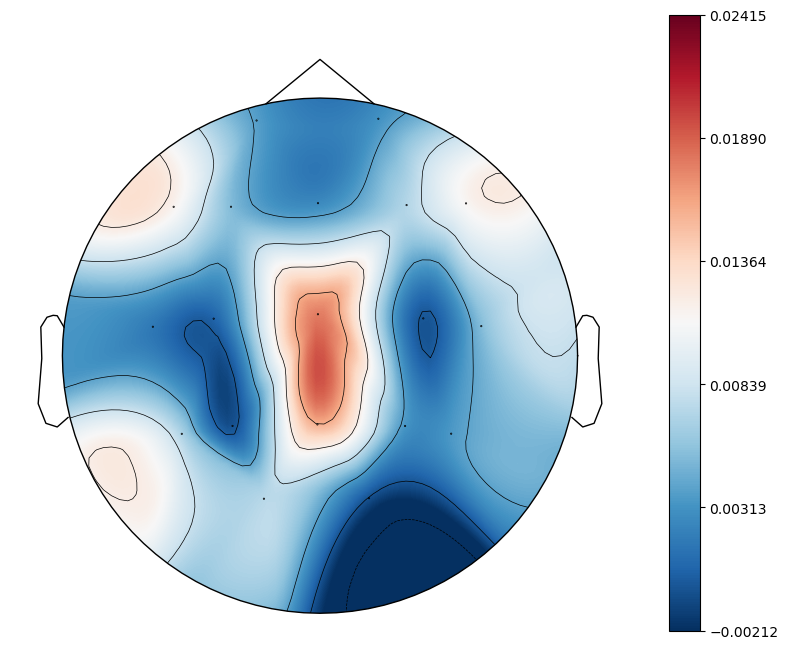

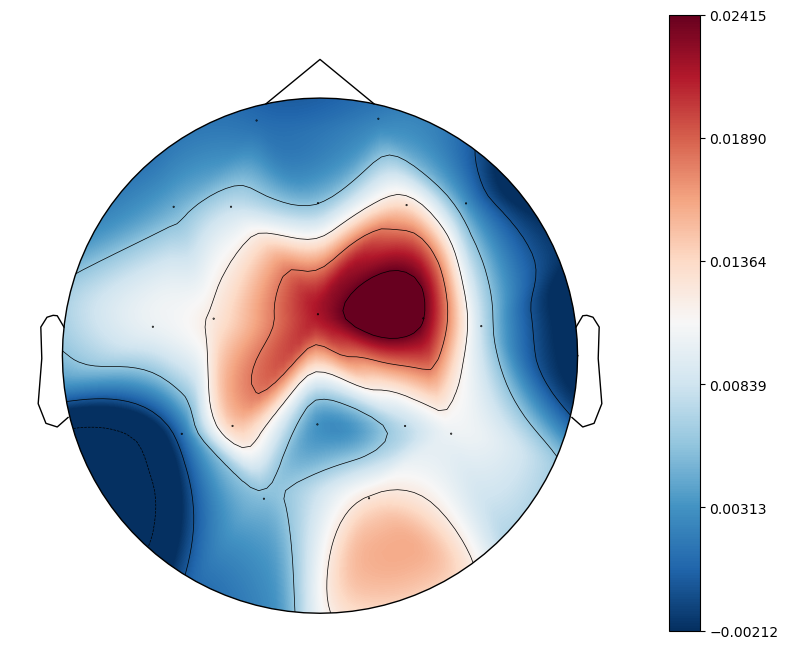

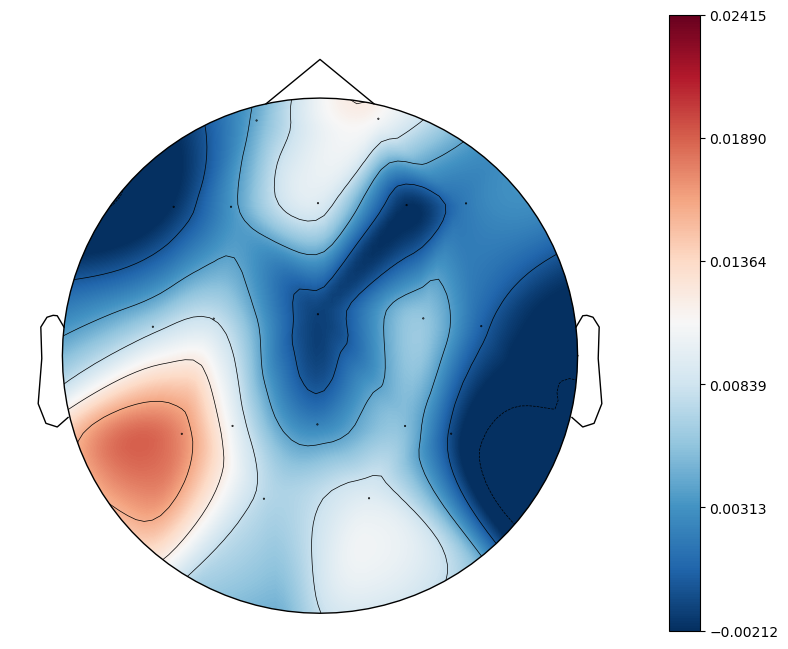

In [ ]:
print(use_age)
generate_occ_plot(raw_occs_all_seeds, use_age=use_age, seeds=[0, 7, 27, 42, 128], save_topomaps=True, use_marker=False)



# Frequency Importance

In [ ]:
print(CAUEEG_RAW)
print(CAUEEG_FM)

In [ ]:
def generate_freq_ablated_dset(orig_dset_signal_pth, freq: tuple, caueeg_raw_pth, filetype="feather", sampling_freq=200):
    """
        freq is a tuple ('band name', low_thresh, high_thresh)

        Setting high and low trans bandwidth to the same value: https://mne.tools/stable/auto_examples/time_frequency/time_frequency_global_field_power.html
    """

    # Get all the names of the eeg files in the dset to filter

    # Loop through each EEG file in the original dset path

    # Check and make sure the destination location exists
    # caueeg_raw_pth / "signal_{freq}" will be the new root dir.
    dset_dest_location = caueeg_raw_pth / f"signal_{freq[0]}" / "signal" / "feather"
    os.makedirs(dset_dest_location, exist_ok=True)


    for f in tqdm(glob.glob(os.path.join(orig_dset_signal_pth, "*.feather"))):

        serial = Path(f).stem
        df = feather.read_feather(f)

        signal_np = df.values
        channel_names = df.columns
        
        signal_np = signal_np.T.astype(np.float64) 
        signal_np /= 1000000 # Convert from uV to V
        signal_np_f = mne.filter.filter_data(
            signal_np,
            sfreq=200,
            l_freq=freq[2], 
            h_freq=freq[1], 
            l_trans_bandwidth=1,
            h_trans_bandwidth=1,
            copy=True,
            picks=list(range(0, 19))
        )

        # Convert back to uV
        signal_np_f *= 1000000

        # Build new df
        df_f = pd.DataFrame(data=signal_np_f.T, columns=channel_names)


        # Save the filtered signal to the destination path
        feather.write_feather(df_f, os.path.join(dset_dest_location, serial + ".feather"))


def get_rel_change_per_cond(reg_accs, freq_accs):

    freq_bands = [("Delta", 0.5, 3.9), ("Theta", 4, 7.9), ("Alpha", 8, 12.9), ("Beta", 13, 29.9), ("Gamma", 30, 90)]
    band_names = [b[0] for b in freq_bands]

    # Get the relative change compared to the non occluded accuracy
    deltas = {}
    for band in band_names:
        deltas[band] = 100 * ((freq_accs[band].numpy() - reg_accs.numpy()) / reg_accs.numpy())
    
    means_per_condition = {"HC":[], "MCI":[], "DEM":[]}
    for band, means in deltas.items():
        means_per_condition["HC"].append(means[0])
        means_per_condition["MCI"].append(means[1])
        means_per_condition["DEM"].append(means[2])

    return means_per_condition

def generate_freq_plot(acc_delta_per_seed, save_plot=False, using_age=True):

    temp = []
    for seed in acc_delta_per_seed.values():
        t = []
        t.extend(seed["HC"])
        t.extend(seed["MCI"])
        t.extend(seed["DEM"])
        temp.append(t)
    
    temp_np = np.array(temp)
    stacked = np.stack(temp_np, axis=1)

    seedwise_means = np.mean(stacked, axis=1).reshape(3, 5)
    seedwise_sem = sem(stacked, axis=1, ddof=1).reshape(3,5)

    means_to_plot = {}
    sems_to_plot = {}
    for i, cond in enumerate(["HC", "MCI", "DEM"]):
        means_to_plot[cond] = seedwise_means[i].tolist()
        sems_to_plot[cond] = seedwise_sem[i].tolist()

    freq_bands = [("Delta", 0.5, 3.9), ("Theta", 4, 7.9), ("Alpha", 8, 12.9), ("Beta", 13, 29.9), ("Gamma", 30, 90)]
    band_names = [b[0] for b in freq_bands]

    x = np.arange(len(band_names))
    width = 0.25
    multiplier = 0

    fig, ax = plt.subplots(layout='constrained', figsize=(10, 5))

    # All HCs = [1, 2, 3, 4, 5]
    bar_colors = ['accent:0', 'accent:1', 'accent:2']
    for cond, d in means_to_plot.items():
        print(cond)
        d = [round(x, 1) for x in d]
        offset = width * multiplier
        if cond == "DEM":
            label = "Dementia"
        else:
            label=cond
        rects = ax.bar(x + offset, d, width, label=label, yerr=sems_to_plot[cond], capsize=5)
        ax.bar_label(rects, padding=3, fontsize=13)
        multiplier += 1

    ax.set_ylabel('Acc. Change (%)', fontsize=18)
    ax.set_title('')
    ax.set_xticks(x + width, band_names)
    ax.legend(loc='lower left', ncols=1, prop={'size': 15})
    ax.set_ylim(-50, 50)
    ax.axhline(y=0, color='k', linestyle='--')
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=15)

    if save_plot:
        age = "_age" if using_age else ""
        plt.savefig(f"freq_bars{age}.png")

    plt.show()

In [ ]:
# RUN THIS CELL TO GENERATE THE DATASETS FOR EACH OF THE FREQUENCY OCCLUSIONS BEOFRE GENERATING THE FREQ OCCLUSIONS


# #freq_bands = [("Delta", 0.5, 3.9), ("Theta", 4, 7.9), ("Alpha", 8, 12.9), ("Beta", 13, 29.9), ("Gamma", 30, 90)]
# signal_path = CAUEEG_RAW / "signal" / "feather"

# for freq in freq_bands:
    
#     # Generate the dataset
#     generate_freq_ablated_dset(signal_path, freq=freq, caueeg_raw_pth=CAUEEG_RAW)



In [7]:
################# GLOBAL PARAMETERS ################################
# Parameters in this cell will require a notebook reset if changed #
use_age = True
use_v2=True

# Get the device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

###################################################################

In [ ]:
def freq_ablation_v2(model, seed, use_age):
    # Creates dataloader and cfg using the modified data paths for that particular frequency ablation

    iter_freqs = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
    freq_accs = {"Delta":None, "Theta": None, "Alpha":None, "Beta":None, "Gamma":None}
    for band in iter_freqs:

        print(band)

        # Get the cfg and dataloaders
        cfg_band = get_configv2(seed, use_age=use_age)

        # Modify the filemarker name
        cfg_band['data']['file_marker_name'] = f"{band}.json"

        # Get the dataloaders and preprocessing
        signal_root_band = CAUEEG_RAW / f"signal_{band}"
        print(f"Loading signals from {signal_root_band}")
        cfg_band, dataloaders, preprocess_test = get_task_cfg_dloaders(seed, cfg_band, use_age=use_age, signal_root=signal_root_band)
        
        # Get the accuracy of the model for this band

        true_labels = []
        scores = []
        preds = []
        for b in tqdm(dataloaders["test"]):

            preprocess_test(b)

            x = b["signal"]
            y = b["class_label"]
            age = b["age"]
            output = model(x, age)

            preds.append(output.argmax(dim=1))
            scores.append(output.detach().cpu()) 
            true_labels.append(y)

        test_scores = torch.cat(scores, dim=0)
        test_labels = torch.cat(true_labels, dim=0)
        mc_acc = multiclass_accuracy(preds=test_scores.detach().cpu(), target=test_labels.detach().cpu(), num_classes=3, average=None)

        freq_accs[band] = mc_acc # {freq_name : freq_acc}

        del cfg_band
        del dataloaders["train"]
        del dataloaders["validation"]
        del dataloaders["test"]
        del dataloaders
        del preprocess_test

    return freq_accs

In [ ]:
rel_change_per_seed = {}
reg_accs_per_seed = {}

for seed in [0, 7, 27, 42, 128]:


    # # Getting the accuracies without the frequencies occluded ---------------------------

    # # Get the base config
    cfg = get_configv2(seed, use_age=use_age)

    # # Get the dataloaders and preprocessing
    cfg, dataloaders, preprocess_test = get_task_cfg_dloaders(seed, cfg, use_age=use_age)
    
    # # Get the saved models
    model = get_model(cfg, seed, use_age=use_age, device=device, v2=use_v2)

    # # Get the accuracy without the frequency occluded
    _, test_labels, _, test_scores = test_epoch_windows(cfg, model, dataloaders["test"], preprocess_test)
    print("Obtaining regular accuracies...")
    reg_accs = multiclass_accuracy(test_scores.detach().cpu(), test_labels.detach().cpu(), num_classes=3, average=None)
    reg_accs_per_seed[seed] = reg_accs.numpy()

    del cfg
    del dataloaders["train"]
    del dataloaders["validation"]
    del dataloaders["test"]
    del dataloaders
    del preprocess_test
    del _
    del test_labels
    del test_scores


    # Getting the accuracies WITH the frequencies occluded -----------------------------

    # Get the dataloaders and preprocessing with the filtered dataset
    print("Obtaining occluded accuracies...")
    accs = freq_ablation_v2(model=model, seed=seed, use_age=use_age)    

    # # Get the relative increase to the non-occluded frequency
    rel_change_per_seed[seed] = get_rel_change_per_cond(reg_accs, accs)
    
    del model




In [14]:
generate_freq_plot(rel_change_per_seed, save_plot=True)

HC
MCI
DEM


In [15]:
rel_change_per_seed

{0: {'HC': [-15.431103, -6.8896027, -5.398872, -13.738918, 2.3368227],
  'MCI': [-1.5018775, 11.952437, -25.969961, 2.6282825, -10.2002535],
  'DEM': [38.108887, -47.182423, 42.40688, 2.1012444, -1.4326645]},
 7: {'HC': [-8.70981, -4.029306, -0.325599, -10.419212, 1.3430996],
  'MCI': [-4.438965, 7.213316, -24.969175, -2.3427901, -3.5758357],
  'DEM': [27.314383, -44.179653, 42.438133, 7.332716, -3.299727]},
 27: {'HC': [-11.373037, -4.7973557, -4.5905704, -10.587264, 0.7030612],
  'MCI': [-1.8360658, 9.180329, -17.967213, 2.4918003, -3.1475413],
  'DEM': [33.159264, -41.94952, 34.116615, 3.5683177, -5.483029]},
 42: {'HC': [-14.291581, -5.708421, -1.4373769, -13.141688, 0.8624231],
  'MCI': [-8.7538, 7.5379953, -26.200607, -2.249245, -4.9240174],
  'DEM': [43.452957, -38.99127, 45.004852, 15.712902, -2.2308402]},
 128: {'HC': [-11.803821, -4.862842, -2.0365708, -12.4688225, 2.6184547],
  'MCI': [-2.2797277, 10.720886, -23.721506, -2.2797277, -8.872459],
  'DEM': [28.207376, -42.794373

In [17]:
reg_accs_per_seed

{0: array([0.81995374, 0.47701493, 0.43300247], dtype=float32),
 7: array([0.81169474, 0.4841791 , 0.45119935], dtype=float32),
 27: array([0.7988107, 0.4552239, 0.4751861], dtype=float32),
 42: array([0.80442685, 0.4910448 , 0.42638543], dtype=float32),
 128: array([0.79484636, 0.4844776 , 0.4706369 ], dtype=float32)}